# 选股＋双均线择时＋风险仓位＋回测

这是一篇可独立运行的 A 股小实验：**API 获取数据 → PE 选 10 只 → MA5/MA15 双均线 → 按风险分三次建仓 → 浮动止盈/止损 → 与沪深 300 比较**。所有必要代码都在本笔记本内。

研究区间为 **2026-01-05 至 2026-09-30**，模拟本金 **10 万元**。每 5 个交易日从固定的沪深 300 成分股中选 10 只。下面的百分比风险预算是对**入场时预估损失**的约束，不是账户亏损上限：跳空、停牌和下一开盘成交都会让实际亏损超过预算。

## 模块 0｜准备：安装和统一参数

在 Python 3.10+ 环境安装 `pip install pandas numpy matplotlib Pillow baostock ipython`。本例不需要行情付费账号；但 BaoStock 需要能访问其 TCP 服务，东方财富需要 HTTPS 网络。把原始数据存在相对目录 `data/private/`，下次运行直接读缓存。

In [1]:
import json
import time
import urllib.parse
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Image as NotebookImage

DATA = Path('data/private')
DATA.mkdir(parents=True, exist_ok=True)
START_DATE, FIRST_DAY, END_DATE = '2025-12-01', '2026-01-05', '2026-09-30'
# 三段按收益所属交易日划分，不重复计算任何一天。
TRAIN_START, TRAIN_END = FIRST_DAY, '2026-03-31'
DEV_START, DEV_END = '2026-04-01', '2026-06-30'
TEST_START, TEST_END = '2026-07-01', END_DATE
SPLIT_WINDOWS = [('训练集（确认逻辑）', TRAIN_START, TRAIN_END),
                 ('开发集（调整参数）', DEV_START, DEV_END),
                 ('测试集（仅验证）', TEST_START, TEST_END)]
POOL_SIZE, PE_LOWER, PE_UPPER, REBALANCE_EVERY = 10, 8.0, 30.0, 5
MA_FAST, MA_SLOW, ATR_WINDOW = 5, 15, 14
INITIAL_CASH = 100_000.0
COMMISSION_RATE, MIN_COMMISSION = 0.0003, 5.0   # 券商万三；每笔佣金最低 5 元
STAMP_DUTY_RATE = 0.0005                       # 2026 年卖出印花税：万分之五
TRANSFER_RATE = 0.00001                        # 过户费双边：十万分之一
TOTAL_RISK, NAME_RISK, MAX_NAME_WEIGHT = 0.03, 0.01, 0.30
RISK_BUFFER = 0.95  # 下单时只用 95% 的组合风险预算，给费用和净值波动留余量
INITIAL_STOP, ARM_GAIN, TRAIL_BACK = 0.025, 0.08, 0.025
ATR_MULT, TRANCHES, ADD_PROFIT_STEP = 1.5, 3, 0.02  # 两次加仓阈值：+2%、+4%
BAR_FIELDS = 'date,code,open,high,low,close,volume,amount,tradestatus,peTTM,isST'
REPORT_DATES = ('2025-09-30', '2025-12-31', '2026-03-31', '2026-06-30')
EASTMONEY_API = 'https://datacenter-web.eastmoney.com/api/data/v1/get'

font_path = Path('video/assets/NotoSansCJKsc-Regular.otf')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_path)).get_name()
plt.rcParams['axes.unicode_minus'] = False

## 参数地图｜哪些旋钮可以转，哪些口径不能拿来“调收益”

先看全貌，再做实验。下图把**所有直接控制这个示例的参数**列在一起；括号内是当前值。股票池仍固定为沪深 300 的 10 只，不能把换指数当作“微调同一策略”。百分比要认清分母：`TOTAL_RISK` 和 `NAME_RISK` 都是占**账户净值**的计划亏损预算，`INITIAL_STOP` 是占**个股买价**的跌幅，`TRAIL_BACK` 是相对**持仓后的最高价**的回撤。前两者控制买多少，后两者控制何时尝试卖，单位不能混用。

可研究的旋钮是 PE 范围、调池周期、两条均线、ATR 估计、风险预算、单股市值上限、分批和退出阈值。资金、回测日期和交易费率也能修改，但它们分别是**实验条件**和**成本假设**，不应为了抬高收益而调低费用或偷换样本区间。参数之间有约束：`MA_FAST < MA_SLOW`、`NAME_RISK ≤ TOTAL_RISK`、`PE_LOWER < PE_UPPER`；每个组合都必须用同一数据、费用和基准比较。


findfont: Failed to find font weight bold for Noto Sans CJK SC, now using 400.


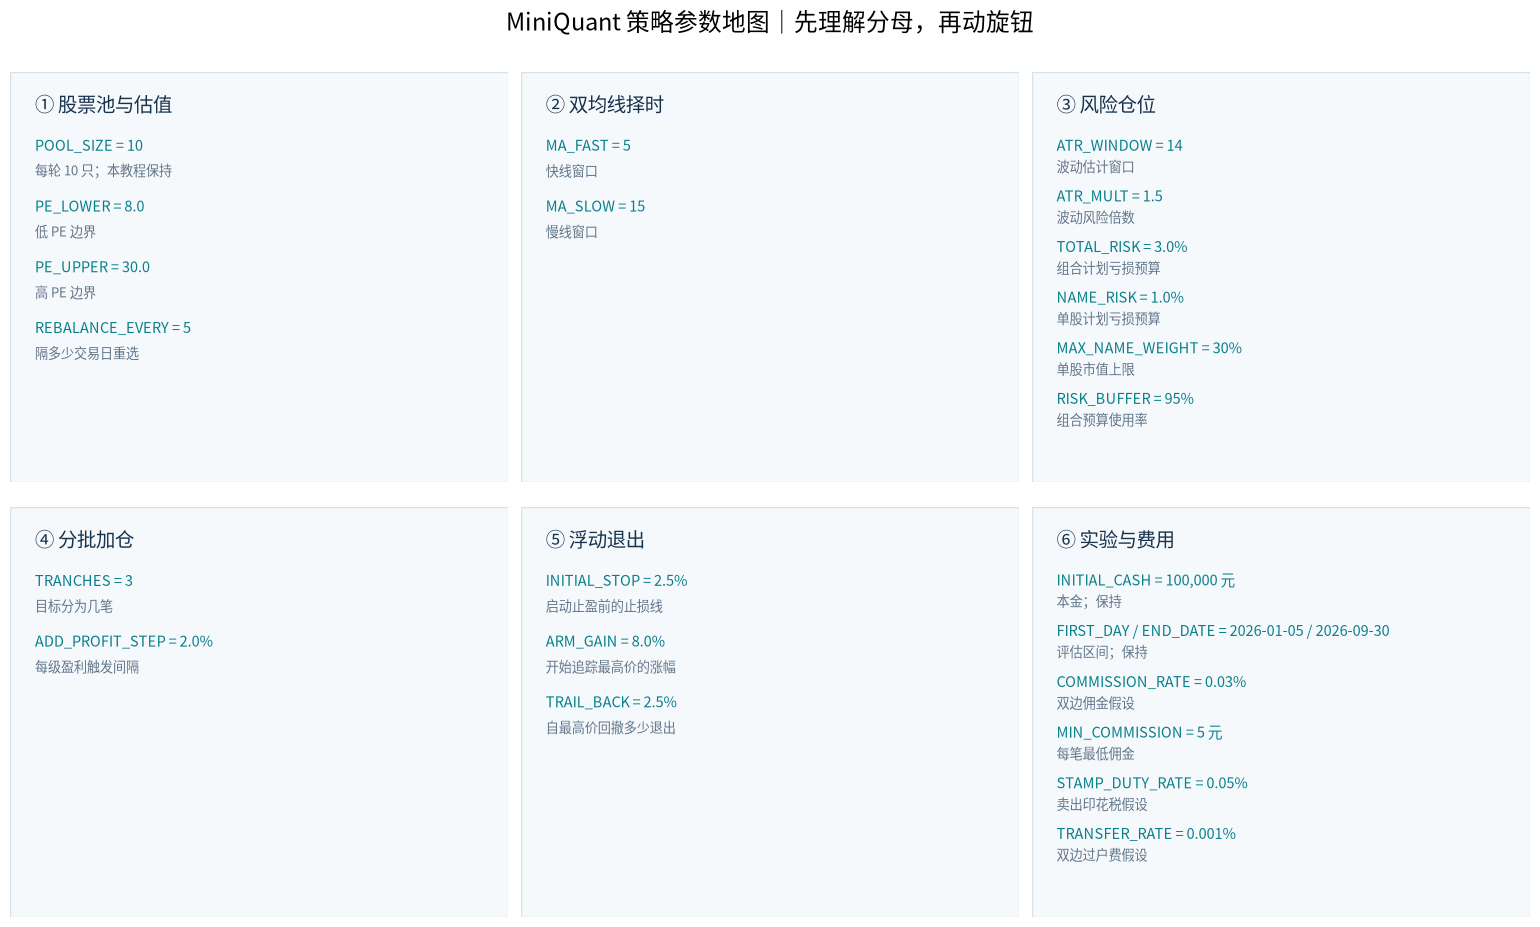

In [2]:
# 图中一行就是一个可以在上面参数单元修改的旋钮；“保持”表示本教程固定研究设定。
parameter_groups = {
    '① 股票池与估值': [
        ('POOL_SIZE', POOL_SIZE, '每轮 10 只；本教程保持'),
        ('PE_LOWER', PE_LOWER, '低 PE 边界'),
        ('PE_UPPER', PE_UPPER, '高 PE 边界'),
        ('REBALANCE_EVERY', REBALANCE_EVERY, '隔多少交易日重选'),
    ],
    '② 双均线择时': [
        ('MA_FAST', MA_FAST, '快线窗口'),
        ('MA_SLOW', MA_SLOW, '慢线窗口'),
    ],
    '③ 风险仓位': [
        ('ATR_WINDOW', ATR_WINDOW, '波动估计窗口'),
        ('ATR_MULT', ATR_MULT, '波动风险倍数'),
        ('TOTAL_RISK', f'{TOTAL_RISK:.1%}', '组合计划亏损预算'),
        ('NAME_RISK', f'{NAME_RISK:.1%}', '单股计划亏损预算'),
        ('MAX_NAME_WEIGHT', f'{MAX_NAME_WEIGHT:.0%}', '单股市值上限'),
        ('RISK_BUFFER', f'{RISK_BUFFER:.0%}', '组合预算使用率'),
    ],
    '④ 分批加仓': [
        ('TRANCHES', TRANCHES, '目标分为几笔'),
        ('ADD_PROFIT_STEP', f'{ADD_PROFIT_STEP:.1%}', '每级盈利触发间隔'),
    ],
    '⑤ 浮动退出': [
        ('INITIAL_STOP', f'{INITIAL_STOP:.1%}', '启动止盈前的止损线'),
        ('ARM_GAIN', f'{ARM_GAIN:.1%}', '开始追踪最高价的涨幅'),
        ('TRAIL_BACK', f'{TRAIL_BACK:.1%}', '自最高价回撤多少退出'),
    ],
    '⑥ 实验与费用': [
        ('INITIAL_CASH', f'{INITIAL_CASH:,.0f} 元', '本金；保持'),
        ('FIRST_DAY / END_DATE', f'{FIRST_DAY} / {END_DATE}', '评估区间；保持'),
        ('COMMISSION_RATE', f'{COMMISSION_RATE:.2%}', '双边佣金假设'),
        ('MIN_COMMISSION', f'{MIN_COMMISSION:.0f} 元', '每笔最低佣金'),
        ('STAMP_DUTY_RATE', f'{STAMP_DUTY_RATE:.2%}', '卖出印花税假设'),
        ('TRANSFER_RATE', f'{TRANSFER_RATE:.3%}', '双边过户费假设'),
    ],
}
from matplotlib.patches import Rectangle
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5), facecolor='white')
for ax, (group_name, items) in zip(axes.flat, parameter_groups.items()):
    ax.set_axis_off()
    ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                               facecolor='#f6f9fb', edgecolor='#d6e2e9', linewidth=1))
    ax.text(.05, .92, group_name, transform=ax.transAxes,
            fontsize=14, weight='bold', color='#17324d', va='center')
    top, step = .82, .74 / max(len(items), 5)
    for k, (name, value, meaning) in enumerate(items):
        y=top-k*step
        ax.text(.05, y, f'{name} = {value}', transform=ax.transAxes,
                fontsize=10.5, color='#087f8c', va='center')
        ax.text(.05, y-step*.42, meaning, transform=ax.transAxes,
                fontsize=9.5, color='#60758a', va='center')
fig.suptitle('MiniQuant 策略参数地图｜先理解分母，再动旋钮', fontsize=17, y=.995)
fig.subplots_adjust(left=.025,right=.975,top=.93,bottom=.04,wspace=.025,hspace=.06)
plt.show()


## 模块 1｜用 BaoStock API 获取日线和指数

先查询 **2026-01-05 的沪深 300 成分股**，把这 300 只作为固定研究范围；再逐只请求日 K 线。`adjustflag='1'` 表示**后复权**：适合近似比较跨分红送转的收益，但价格和“股数”不能直接拿来实盘下单。`peTTM` 是数据源给出的滚动市盈率；`tradestatus` 和 `isST` 帮助排除不能按规则交易的股票。2025-12-01 开始抓取，是给 MA15 留预热数据。

沪深 300（`sh.000300`）是本节**基准**；上证综指（`sh.000001`）仅作背景。指数用不复权值 `adjustflag='3'`。下面的函数在文件不存在时下载，已有缓存则直接读取。

In [3]:
def rows(result, label: str) -> pd.DataFrame:
    if result.error_code != "0":
        raise RuntimeError(f"{label}: {result.error_code} {result.error_msg}")
    records = []
    while result.next():
        records.append(result.get_row_data())
    return pd.DataFrame(records, columns=result.fields)


def load_or_fetch_baostock():
    names = ['simple_2026_members.csv.gz', 'simple_2026_bars.csv.gz',
             'simple_2026_benchmark.csv.gz', 'simple_2026_shanghai.csv.gz']
    paths = [DATA / name for name in names]
    if not all(path.exists() for path in paths):
        import baostock as bs
        login = bs.login()
        if login.error_code != '0':
            raise RuntimeError(f'BaoStock 登录失败：{login.error_msg}')
        try:
            members = rows(bs.query_hs300_stocks(date=FIRST_DAY), '沪深300成分股')
            codes = sorted(members.code.unique())
            if not 250 <= len(codes) <= 350:
                raise ValueError(f'成分股数量异常：{len(codes)}')
            parts = []
            for i, code in enumerate(codes, 1):
                result = bs.query_history_k_data_plus(
                    code, BAR_FIELDS, start_date=START_DATE,
                    end_date=END_DATE, frequency='d', adjustflag='1')
                parts.append(rows(result, code))
                if i % 50 == 0:
                    print(f'BaoStock 已获取 {i}/{len(codes)} 只')
            bars = pd.concat(parts, ignore_index=True)
            benchmark = rows(bs.query_history_k_data_plus(
                'sh.000300', 'date,code,open,close',
                start_date=START_DATE, end_date=END_DATE,
                frequency='d', adjustflag='3'), '沪深300指数')
            shanghai = rows(bs.query_history_k_data_plus(
                'sh.000001', 'date,code,open,close',
                start_date=START_DATE, end_date=END_DATE,
                frequency='d', adjustflag='3'), '上证综指')
        finally:
            bs.logout()
        for frame, path in zip((members, bars, benchmark, shanghai), paths):
            frame.to_csv(path, index=False, compression='gzip')
    members = pd.read_csv(paths[0], dtype={'code': str})
    bars = pd.read_csv(paths[1], dtype={'code': str})
    benchmark = pd.read_csv(paths[2])
    shanghai = pd.read_csv(paths[3])
    return members, bars, benchmark, shanghai

members_raw, bars_raw, benchmark_raw, shanghai_raw = load_or_fetch_baostock()
print(f'成分股 {len(members_raw)} 只；日线 {len(bars_raw):,} 行；最后交易日 {bars_raw.date.max()}')
display(bars_raw[['date', 'code', 'open', 'close', 'peTTM']].head(3))

成分股 300 只；日线 61,200 行；最后交易日 2026-09-30


,date,code,open,close,peTTM
0,2025-12-01,sh.600000,145.637137,147.296456,7.867467
1,2025-12-01,sh.600009,83.540100,84.547565,33.533784
2,2025-12-01,sh.600010,17.668255,18.030309,111.250461


## 模块 2｜用东方财富 API 获取财报

技术指标只看价格，基本面还要看财报。本例按报告期分页请求东方财富数据中心的 `RPT_LICO_FN_CPD`，只保留研究股票的公告日期、更新日期和每股收益（EPS）等字段。网页接口可能变化或限流；**报告期不是公布日期**，回测必须等到财报实际可用后才使用。东财历史网页会被修订，因此这仍不是严格的逐日历史快照。

In [4]:
def eastmoney_page(report_date: str, page: int, retries: int = 3) -> dict:
    params = {
        "sortColumns": "UPDATE_DATE,SECURITY_CODE",
        "sortTypes": "-1,-1",
        "pageSize": "500",
        "pageNumber": str(page),
        "reportName": "RPT_LICO_FN_CPD",
        "columns": "ALL",
        "filter": f"(REPORTDATE='{report_date}')",
    }
    url = EASTMONEY_API + "?" + urllib.parse.urlencode(params)
    request = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0 MiniQuant educational snapshot",
            "Referer": "https://data.eastmoney.com/bbsj/",
        },
    )
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(request, timeout=20) as response:
                payload = json.load(response)
            if payload.get("success") is not True or not payload.get("result"):
                raise ValueError(f"Eastmoney response changed: {payload.get('message')}")
            return payload["result"]
        except (OSError, ValueError) as exc:
            if attempt == retries - 1:
                raise RuntimeError(f"Eastmoney {report_date} page {page}") from exc
            time.sleep(1.5 * (attempt + 1))
    raise AssertionError("unreachable")


def fetch_reports(codes: set[str]) -> pd.DataFrame:
    all_rows = []
    for report_date in REPORT_DATES:
        first = eastmoney_page(report_date, 1)
        pages = int(first["pages"])
        expected_count = int(first["count"])
        raw = list(first.get("data") or [])
        for page in range(2, pages + 1):
            raw.extend(eastmoney_page(report_date, page).get("data") or [])
            time.sleep(0.08)
        if len(raw) != expected_count:
            raise ValueError(f"Eastmoney {report_date}: expected {expected_count}, got {len(raw)}")
        kept = [r for r in raw if str(r.get("SECURITY_CODE", "")).zfill(6) in codes]
        all_rows.extend(kept)
        print(f"Eastmoney {report_date}: {len(raw)} raw / {len(kept)} in universe", flush=True)
    if not all_rows:
        raise ValueError("No reports matched the chosen stocks")
    out = pd.DataFrame(all_rows)
    keep = [
        "SECURITY_CODE", "SECURITY_NAME_ABBR", "TRADE_MARKET", "REPORTDATE",
        "NOTICE_DATE", "UPDATE_DATE", "BASIC_EPS", "PARENT_NETPROFIT",
        "TOTAL_OPERATE_INCOME", "BOARD_NAME",
    ]
    missing = set(keep).difference(out.columns)
    if missing:
        raise ValueError(f"Eastmoney missing columns: {sorted(missing)}")
    return out[keep]


def load_or_fetch_reports(members):
    path = DATA / 'simple_2026_reports.csv.gz'
    if not path.exists():
        codes = {code.split('.')[-1] for code in members.code}
        fetch_reports(codes).to_csv(path, index=False, compression='gzip')
    return pd.read_csv(path, dtype={'SECURITY_CODE': str})

reports_raw = load_or_fetch_reports(members_raw)
print(f'财报 {len(reports_raw):,} 行；示例字段：')
display(reports_raw[['SECURITY_CODE', 'REPORTDATE', 'NOTICE_DATE',
                     'UPDATE_DATE', 'BASIC_EPS']].head(3))

财报 1,200 行；示例字段：


,SECURITY_CODE,REPORTDATE,NOTICE_DATE,UPDATE_DATE,BASIC_EPS
0,000858,2025-09-30 00:00:00,2025-10-31 00:00:00,2026-04-30 00:00:00,1.6680
1,300122,2025-09-30 00:00:00,2025-10-30 00:00:00,2026-04-28 00:00:00,-0.5547
2,688981,2025-09-30 00:00:00,2025-11-14 00:00:00,2025-11-14 00:00:00,0.4800


## 模块 3｜清洗数据，计算双均线和波动

真实接口的数字常是字符串，也可能有空值、重复或异常价格。下面校验日线与财报；分别计算 MA5、MA15、金叉/死叉，以及 ATR14（日均真实波幅）。ATR 只用于**保守估计仓位大小**：同样的风险预算，波动大的股票买得少。

**PE（市盈率）≈ 股价 ÷ 过去 12 个月每股收益**。股价 10 元、过去一年每股赚 1 元，PE 约 10 倍。`peTTM` 的 TTM 指滚动 12 个月。低 PE 不必然是好股票；表中的后复权 `close` 也不能直接与单季度 EPS 相除来重算 PE。

In [5]:
def clean_inputs(bars, reports, members, benchmark, ma_window=MA_SLOW):
    """Apply an explicit schema; return clean tables and a small rejection audit."""
    if ma_window < 2:
        raise ValueError("ma_window must be at least 2")
    bars = bars.copy()
    reports = reports.copy()
    members = members.copy()
    benchmark = benchmark.copy()
    audit = {}

    if bars.duplicated(["date", "code"]).any():
        raise ValueError("BaoStock date/code is not unique")
    bars["date"] = pd.to_datetime(bars["date"], errors="coerce")
    for col in ("open", "high", "low", "close", "volume", "amount", "peTTM"):
        bars[col] = pd.to_numeric(bars[col], errors="coerce")
    for col in ("tradestatus", "isST"):
        bars[col] = pd.to_numeric(bars[col], errors="coerce")
    invalid_price = (
        bars["date"].isna() | (bars[["open", "high", "low", "close"]] <= 0).any(axis=1)
        | (bars["high"] < bars[["open", "close"]].max(axis=1))
        | (bars["low"] > bars[["open", "close"]].min(axis=1))
        | (bars["volume"] < 0)
    )
    audit["bad_price_rows"] = int(invalid_price.sum())
    if invalid_price.any():
        raise ValueError(f"Invalid OHLC/volume in {invalid_price.sum()} rows")
    audit["suspended_rows"] = int((bars["tradestatus"] != 1).sum())
    audit["invalid_pe_rows"] = int((~bars["peTTM"].between(PE_LOWER, PE_UPPER, inclusive="neither")).sum())
    bars = bars.sort_values(["code", "date"]).reset_index(drop=True)
    group = bars.groupby('code', sort=False)['close']
    bars['fast_ma'] = group.transform(lambda x: x.rolling(MA_FAST, min_periods=MA_FAST).mean())
    bars['slow_ma'] = group.transform(lambda x: x.rolling(ma_window, min_periods=ma_window).mean())
    bars['prev_close'] = group.shift(1)
    bars['prev_fast'] = bars.groupby('code', sort=False)['fast_ma'].shift(1)
    bars['prev_slow'] = bars.groupby('code', sort=False)['slow_ma'].shift(1)
    true_range = pd.concat([
        bars.high - bars.low,
        (bars.high - bars.prev_close).abs(),
        (bars.low - bars.prev_close).abs(),
    ], axis=1).max(axis=1)
    bars['true_range'] = true_range
    bars['atr14'] = bars.groupby('code', sort=False)['true_range'].transform(
        lambda x: x.rolling(ATR_WINDOW, min_periods=ATR_WINDOW).mean())
    tradable = bars.tradestatus.eq(1) & bars.volume.gt(0)
    bars['golden_cross'] = (tradable & bars.fast_ma.gt(bars.slow_ma)
                            & bars.prev_fast.le(bars.prev_slow))
    bars['dead_cross'] = (tradable & bars.fast_ma.lt(bars.slow_ma)
                          & bars.prev_fast.ge(bars.prev_slow))

    reports["code6"] = reports["SECURITY_CODE"].str.zfill(6)
    for col in ("REPORTDATE", "NOTICE_DATE", "UPDATE_DATE"):
        reports[col] = pd.to_datetime(reports[col], errors="coerce").dt.normalize()
    for col in ("BASIC_EPS", "PARENT_NETPROFIT", "TOTAL_OPERATE_INCOME"):
        reports[col] = pd.to_numeric(reports[col], errors="coerce")
    bad_report = (
        ~reports["code6"].str.fullmatch(r"\d{6}", na=False)
        | reports[["REPORTDATE", "NOTICE_DATE", "UPDATE_DATE"]].isna().any(axis=1)
        | (reports["REPORTDATE"] > reports["NOTICE_DATE"])
    )
    audit["bad_report_rows"] = int(bad_report.sum())
    reports = reports.loc[~bad_report].copy()
    # A retrospective correction can change a value. Use the later date as a
    # conservative *earliest usable* date; this is still not a true PIT archive.
    reports["available_on"] = reports[["NOTICE_DATE", "UPDATE_DATE"]].max(axis=1)
    audit["missing_eps_rows"] = int(reports["BASIC_EPS"].isna().sum())
    reports = reports.drop_duplicates(["code6", "REPORTDATE", "available_on"], keep="last")

    members = members.drop_duplicates("code")
    if len(members) != 300:
        raise ValueError(f"Expected 300 fixed index constituents, got {len(members)}")
    if not set(bars["code"]).issubset(set(members["code"])):
        raise ValueError("Price data contains stocks outside the fixed CSI 300 universe")
    benchmark["date"] = pd.to_datetime(benchmark["date"], errors="coerce")
    for col in ("open", "close"):
        benchmark[col] = pd.to_numeric(benchmark[col], errors="coerce")
    if benchmark["date"].isna().any() or (benchmark[["open", "close"]] <= 0).any().any():
        raise ValueError("Bad benchmark date/price")
    benchmark = benchmark.drop_duplicates("date").sort_values("date").reset_index(drop=True)
    return bars, reports, members, benchmark, audit


bars, reports, members, benchmark, audit = clean_inputs(
    bars_raw, reports_raw, members_raw, benchmark_raw)
print('清洗审计：', audit)
print('可用日线：', bars.date.min().date(), '至', bars.date.max().date())

清洗审计： {'bad_price_rows': 0, 'suspended_rows': 98, 'invalid_pe_rows': 29793, 'bad_report_rows': 0, 'missing_eps_rows': 0}
可用日线： 2025-12-01 至 2026-09-30


## 模块 4｜PE 选股：每 5 个交易日保留 10 只

只用**此前已公告、EPS 为正**的财报；在当天有交易、非 ST、`8 < PE < 30` 且有足够 MA15 历史的沪深 300 股票中，按 PE 从小到大取 10 只。选股和建仓不同：股票池有 10 只，真正持有几只由后面的双均线与风险预算决定。

In [6]:
def latest_public_report(reports: pd.DataFrame, decision_date: pd.Timestamp) -> pd.DataFrame:
    """Strictly earlier published/revised rows only; same-day reports are excluded."""
    known = reports.loc[
        (reports["available_on"] < decision_date)
        & (reports["BASIC_EPS"] > 0)
    ]
    return known.sort_values(["code6", "REPORTDATE", "available_on"]).drop_duplicates(
        "code6", keep="last"
    )


def select_pool(day_bars: pd.DataFrame, reports: pd.DataFrame, day: pd.Timestamp, size=POOL_SIZE):
    """Select the lowest PE in (8, 30) among tradable members with known reports."""
    report_codes = set(latest_public_report(reports, day)["code6"])
    eligible = day_bars.loc[
        day_bars["peTTM"].between(PE_LOWER, PE_UPPER, inclusive="neither")
        & (day_bars["tradestatus"] == 1)
        & (day_bars["volume"] > 0)
        & (day_bars["isST"] == 0)
        & day_bars["slow_ma"].notna()
        & day_bars["code"].str[-6:].isin(report_codes)
    ].sort_values(["peTTM", "code"])
    chosen = eligible.head(size)
    if len(chosen) != size:
        raise ValueError(f"Only {len(chosen)} eligible stocks on {day.date()}, need {size}")
    return list(chosen["code"]), len(eligible)


first_day = pd.Timestamp(FIRST_DAY)
pool, eligible_count = select_pool(bars.loc[bars.date.eq(first_day)], reports, first_day)
first_pool = bars.loc[bars.date.eq(first_day) & bars.code.isin(pool),
                      ['code', 'peTTM']].sort_values('peTTM')
print(f'首日满足条件 {eligible_count} 只，入池 {len(pool)} 只')
display(first_pool.reset_index(drop=True))

首日满足条件 154 只，入池 10 只


,code,peTTM
0,sh.601628,8.015329
1,sh.600000,8.058359
2,sh.601601,8.280661
3,sh.601669,8.427466
4,sh.600018,8.768559
5,sh.600027,8.835654
6,sh.600023,9.126090
7,sh.601288,9.181036
8,sh.600741,9.204805
9,sh.601318,9.340317


## 模块 5｜择时：MA5/MA15 金叉与死叉

MA5 是近 5 个交易日的平均收盘价，MA15 是近 15 日平均。**金叉**指昨天 MA5 ≤ MA15、今天 MA5 > MA15；只有池内新金叉才触发首笔买入。**死叉**指 MA5 从上方跌到 MA15 下方，触发退出。单纯“MA5 在上方”不是新买点；止损卖出后也不会立刻追买，要等新金叉。信号在当日收盘生成，下一交易日开盘才模拟成交。

In [7]:
def build_decisions(bars, reports, benchmark, first=FIRST_DAY, every=REBALANCE_EVERY):
    """收盘信号：每 5 个交易日调池，MA5/MA15 金叉和死叉单独记录。"""
    dates = list(benchmark.loc[benchmark.date >= pd.Timestamp(first), 'date'])
    by_day = {day: frame for day, frame in bars.groupby('date', sort=False)}
    pool = set()
    records = []
    for i, day in enumerate(dates[:-1]):
        today = by_day[day]
        rebalance = i % every == 0
        eligible_count = None
        if rebalance:
            chosen, eligible_count = select_pool(today, reports, day)
            pool = set(chosen)
        golden = set(today.loc[today.golden_cross, 'code']) & pool
        death = set(today.loc[today.dead_cross, 'code'])
        trend = set(today.loc[today.fast_ma > today.slow_ma, 'code']) & pool
        records.append({
            'signal_date': day, 'execution_date': dates[i + 1], 'rebalance': rebalance,
            'eligible_count': eligible_count, 'pool_count': len(pool),
            'trend_count': len(trend), 'pool': frozenset(pool),
            'golden': frozenset(golden), 'death': frozenset(death),
        })
    return pd.DataFrame(records)


decisions = build_decisions(bars, reports, benchmark, first=FIRST_DAY, every=REBALANCE_EVERY)
display(decisions.loc[decisions.rebalance,
                      ['signal_date', 'execution_date', 'pool_count', 'trend_count']].head(5))
print(f'调池 {int(decisions.rebalance.sum())} 次；股票池始终 10 只')
assert decisions.pool_count.eq(10).all()
assert (decisions.execution_date > decisions.signal_date).all()

,signal_date,execution_date,pool_count,trend_count
0,2026-01-05,2026-01-06,10,6
5,2026-01-12,2026-01-13,10,7
10,2026-01-19,2026-01-20,10,3
15,2026-01-26,2026-01-27,10,4
20,2026-02-02,2026-02-03,10,4


调池 36 次；股票池始终 10 只


## 模块 6｜百分比风险模型、盈利比例加仓与浮动止盈止损

先把三种容易混淆的百分比分开：

1. **账户总风险率** `r_total`：本金或当日组合净值 `C` 最多愿意承担多少计划亏损。本例 `C=100000 元`、`r_total=3%`，总风险预算 `R_total=C×r_total=3000 元`。
2. **个股价格风险率** `r_stock`：从买价到计划止损位的价格距离。若单股买价 `p=40 元`、风险距离 `5%`，每股计划风险金额 `R_unit=p×r_stock=2 元/股`。这里的 **5% 是股价跌幅，不是账户亏损率**；本例实际取 `r_stock=max(2.5%, 1.5×ATR14/信号日收盘价)`，波动越大，距离越宽。
3. **头寸规模**：若只买这一只且不设单股上限，`P=R_total/R_unit=3000/2=1500 股`。但我们同时研究多只股票，必须扣除已有持仓占用风险，并给单只股票设账户风险上限 `r_name=1%`：`R_available=min(R_total−已占用风险, C×r_name)`，所以这个例子的单股预算最多 `1000 元`，`P≈1000/2=500 股`。实际下单还受现金、单只市值上限和逐笔费用约束；本页用后复权价格模拟，数量是**复权单位**，不是真实可下单股数。

代码先按 `P≈R_available/(p×r_stock)` 求不含费用的上限，再用二分法缩小到“**预计价格损失＋买卖佣金、卖出印花税和过户费**”都不超过预算的规模。每只最多分三笔计划等额建立目标仓位；若某笔受剩余风险预算或现金限制，实际三笔金额可能小于计划值。**计划风险不是保证亏损上限**，跳空或停牌仍可能造成更大损失。

**盈利比例均匀加仓**：每只股票记录**首次买入价**与**最近一次买入价**。首笔买入后，某日开盘价相对首次买价的收益达到 **+2%**，计划再买与首笔相同的金额；达到 **+4%**，计划第三笔。还要求开盘价高于最近一次买价、MA5 仍高于 MA15，且该日没有任何待执行的止损、其他退出或新金叉买入信号。每只最多三笔，金额仍受剩余风险预算和现金约束。阈值是可修改的教学参数；下文明确列出仅用训练段选择参数的过程。

**成交时点**：我们在开盘后才知道该日开盘价，不能事后假设自己恰好以同一开盘价买到。因此开盘触发只产生**次日加仓候选**；到下一交易日开盘，再确认价格仍达标、未发生止损/退出或其他新买信号，才模拟成交。这会错过一些机会，但避免了同价观察与成交的前视偏差。

**浮动退出**：若买后从未达到 +8%，收盘跌至持仓均价的 **−2.5%**，给出止损信号；一旦最高收盘价达到持仓均价的 **+8%**，改为当收盘价自该最高价回撤 **2.5%** 时止盈。出池或死叉也退出。所有信号都在收盘判断、下一开盘执行；跳空和停牌可能让实际损失超过 2.5%，因此这里的“止损 2.5%”不是成交保证。

**交易费率**：示例佣金买卖各万三，**每笔至少 5 元**；卖出印花税用 2026 年适用的**万分之五**；过户费买卖各十万分之一。图中卖出印花税千分之一是减半征收前口径，本页另做旧费率敏感性对比。佣金档位及包含项目以实际券商账单为准；三次小额加仓容易反复触发最低 5 元，不能再用固定“单边 10 bps”代替。

In [8]:
def transaction_fee(notional, side, stamp_rate=STAMP_DUTY_RATE):
    """佣金双边且每笔最低 5 元；印花税仅卖出；过户费双边。"""
    if notional <= 0:
        return 0.0, 0.0, 0.0, 0.0
    commission = max(MIN_COMMISSION, notional * COMMISSION_RATE)
    stamp = notional * stamp_rate if side == 'SELL' else 0.0
    transfer = notional * TRANSFER_RATE
    return commission + stamp + transfer, commission, stamp, transfer


def planned_loss(notional, risk_fraction, stamp_rate=STAMP_DUTY_RATE):
    """计划止损金额：价格风险 + 买费 + 一笔保守的卖费。"""
    if notional <= 0:
        return 0.0
    buy_fee = transaction_fee(notional, 'BUY', stamp_rate)[0]
    sell_fee = transaction_fee(notional * (1 - INITIAL_STOP), 'SELL', stamp_rate)[0]
    return notional * risk_fraction + buy_fee + sell_fee


def max_notional_for_risk(budget, risk_fraction, stamp_rate=STAMP_DUTY_RATE):
    """用二分法处理每笔最低佣金造成的非线性。"""
    if budget <= 0:
        return 0.0
    lo, hi = 0.0, budget / risk_fraction
    for _ in range(45):
        mid = (lo + hi) / 2
        if planned_loss(mid, risk_fraction, stamp_rate) <= budget:
            lo = mid
        else:
            hi = mid
    return lo


def run_risk_backtest(bars, benchmark, decisions, *, initial_cash=100_000.0,
                      stamp_rate=STAMP_DUTY_RATE):
    """下一开盘成交；风险预算按入场时的计划损失而非实际最大亏损计算。"""
    if initial_cash <= 0 or stamp_rate < 0:
        raise ValueError('本金与费用设置无效')
    by_day = {day: frame.set_index('code') for day, frame in bars.groupby('date', sort=False)}
    dates = list(benchmark.loc[benchmark.date >= decisions.iloc[0].signal_date, 'date'])
    cash = float(initial_cash)
    positions = {}  # code -> 复权单位、加仓次数、均价、最高收盘价、计划风险
    last_open = {}
    history = [dict(date=dates[0], nav=1.0, equity=cash, cost=0.0,
                    turnover=0.0, holdings=0, blocked=0, planned_risk=0.0, exposure=0.0)]
    trades = []
    position_log = []
    pending_adds = {}  # 本日开盘触发、下一交易日才可能执行的加仓候选

    for i, d in decisions.iterrows():
        signal_day, execution_day = d.signal_date, d.execution_date
        signal = by_day[signal_day]
        current = by_day[execution_day]
        for code, row in current.iterrows():
            if np.isfinite(row.open) and row.open > 0:
                last_open[code] = float(row.open)
        if any(code not in last_open for code in positions):
            raise ValueError(f'{execution_day.date()} 持仓缺少估值价格')
        before = cash + sum(p['units'] * last_open[code] for code, p in positions.items())
        fees = turnover = 0.0
        blocked = 0

        def can_trade(code):
            if code not in current.index:
                return False
            row = current.loc[code]
            return bool(row.tradestatus == 1 and row.volume > 0 and row.open > 0)

        # 先用信号日收盘价检查退出条件；只有下一交易日开盘才实际卖出。
        exits = {}
        for code, p in positions.items():
            if code not in signal.index:
                continue
            close = float(signal.loc[code, 'close'])
            p['peak'] = max(p['peak'], close)
            p['armed'] = p['armed'] or p['peak'] >= p['entry'] * (1 + ARM_GAIN)
            if code not in d.pool:
                exits[code] = 'OUT_OF_POOL'
            elif p['armed']:
                if close <= p['peak'] * (1 - TRAIL_BACK):
                    exits[code] = 'TRAIL_PROFIT'
            elif close <= p['entry'] * (1 - INITIAL_STOP):
                exits[code] = 'STOP_LOSS'
            if code not in exits and code in d.death:
                exits[code] = 'MA_DEATH'

        for code in sorted(exits):
            if not can_trade(code):
                blocked += 1
                continue
            p = positions.pop(code)
            pending_adds.pop(code, None)
            price = last_open[code]
            notional = p['units'] * price
            fee, commission, stamp, transfer = transaction_fee(notional, 'SELL', stamp_rate)
            cash += notional - fee
            fees += fee
            turnover += notional / before
            trades.append((execution_day, signal_day, code, 'SELL', p['units'],
                           price, fee, exits[code], commission, stamp, transfer))

        def risk_used():
            return sum(p['risk_amount'] for p in positions.values())

        def buy_tranche(code, target_notional, risk_fraction, reason, full_notional):
            nonlocal cash, fees, turnover, blocked
            if not can_trade(code):
                blocked += 1
                return False
            price = last_open[code]
            used_by_name = positions[code]['risk_amount'] if code in positions else 0.0
            remaining_name = max(0.0, before * NAME_RISK - used_by_name)
            remaining_total = max(0.0, before * TOTAL_RISK * RISK_BUFFER - risk_used())
            notional = min(target_notional,
                           max_notional_for_risk(remaining_name, risk_fraction, stamp_rate),
                           max_notional_for_risk(remaining_total, risk_fraction, stamp_rate), cash)
            if notional + transaction_fee(notional, 'BUY', stamp_rate)[0] > cash:
                lo, hi = 0.0, notional
                for _ in range(45):
                    mid = (lo + hi) / 2
                    if mid + transaction_fee(mid, 'BUY', stamp_rate)[0] <= cash:
                        lo = mid
                    else:
                        hi = mid
                notional = lo
            if notional <= 1.0:
                return False
            units = notional / price
            fee, commission, stamp, transfer = transaction_fee(notional, 'BUY', stamp_rate)
            this_risk = planned_loss(notional, risk_fraction, stamp_rate)
            old = positions.get(code)
            if old is None:
                positions[code] = dict(units=units, entry=price, peak=price, armed=False,
                                       first_buy_price=price, last_buy_price=price,
                                       risk_fraction=risk_fraction,
                                       risk_amount=this_risk,
                                       full_notional=full_notional, tranches=1,
                                       last_add=i)
            else:
                old_units = old['units']
                old['entry'] = (old['entry'] * old_units + price * units) / (old_units + units)
                old['units'] += units
                old['risk_amount'] += this_risk
                old['tranches'] += 1
                old['last_add'] = i
                old['last_buy_price'] = price
            cash -= notional + fee
            fees += fee
            turnover += notional / before
            trades.append((execution_day, signal_day, code, 'BUY', units,
                           price, fee, reason, commission, stamp, transfer))
            return True

        # 初始建仓：波动越高，每笔的计划风险距离越宽，目标仓位越小。
        new_codes = set()
        for code in sorted(d.golden):
            if code in positions or code in exits or code not in signal.index:
                continue
            row = signal.loc[code]
            if not np.isfinite(row.atr14) or row.close <= 0:
                continue
            risk_fraction = max(INITIAL_STOP, ATR_MULT * row.atr14 / row.close)
            full_notional = min(TRANCHES * max_notional_for_risk(
                                    before * NAME_RISK / TRANCHES,
                                    risk_fraction, stamp_rate),
                                before * MAX_NAME_WEIGHT)
            if buy_tranche(code, full_notional / TRANCHES, risk_fraction,
                           'MA_GOLDEN', full_notional):
                new_codes.add(code)

        # 开盘价触发的是“下一交易日候选”，避免看到开盘价后仍按同一开盘价成交。
        queued = pending_adds
        pending_adds = {}
        clear_day = not exits and not d.golden  # 全组合没有止损/退出或其他新买信号
        added_today = set()
        if clear_day:
            for code, trigger_day in sorted(queued.items()):
                if (code not in positions or code not in d.pool
                        or code not in current.index or code not in signal.index
                        or trigger_day != signal_day):
                    continue
                p = positions[code]
                row = signal.loc[code]
                if (p['tranches'] >= TRANCHES or p['armed']
                        or row.fast_ma <= row.slow_ma or not can_trade(code)):
                    continue
                open_price = last_open[code]
                milestone = ADD_PROFIT_STEP * p['tranches']
                open_profit = open_price / p['first_buy_price'] - 1
                if open_profit < milestone or open_price <= p['last_buy_price']:
                    continue
                if buy_tranche(code, p['full_notional'] / TRANCHES,
                               p['risk_fraction'], f"SCALE_IN_{p['tranches'] + 1}",
                               p['full_notional']):
                    added_today.add(code)

            # 在今天开盘首次达到下一里程碑，排入明天的候选队列。
            for code in sorted(set(positions) - added_today - new_codes):
                p = positions[code]
                if (p['tranches'] >= TRANCHES or p['armed'] or code not in d.pool
                        or code not in signal.index or not can_trade(code)):
                    continue
                if signal.loc[code, 'fast_ma'] <= signal.loc[code, 'slow_ma']:
                    continue
                open_price = last_open[code]
                milestone = ADD_PROFIT_STEP * p['tranches']
                if (open_price / p['first_buy_price'] - 1 >= milestone
                        and open_price > p['last_buy_price']):
                    pending_adds[code] = execution_day

        after = cash + sum(p['units'] * last_open[code] for code, p in positions.items())
        if cash < -1e-6 or after <= 0:
            raise ValueError(f'{execution_day.date()} 现金或净值异常')
        for code, p in positions.items():
            position_log.append((execution_day, code, p['units'], p['tranches'],
                                 p['first_buy_price'], p['last_buy_price'],
                                 last_open[code] / p['first_buy_price'] - 1))
        history.append(dict(date=execution_day, nav=after / initial_cash,
                            equity=after, cost=fees / initial_cash,
                            turnover=turnover, holdings=len(positions),
                            blocked=blocked, planned_risk=risk_used(),
                            exposure=sum(p['units'] * last_open[code]
                                         for code, p in positions.items()) / after))

    nav = pd.DataFrame(history).set_index('date')
    trades = pd.DataFrame(trades, columns=[
        'date', 'signal_date', 'code', 'side', 'units', 'adjusted_price',
        'fee', 'reason', 'commission', 'stamp', 'transfer'])
    benchmark_open = benchmark.set_index('date')['open'].reindex(nav.index)
    if benchmark_open.isna().any():
        raise ValueError('基准日期不完整')
    nav['benchmark_nav'] = benchmark_open / benchmark_open.iloc[0]
    nav['return'] = nav.nav.pct_change()
    nav['benchmark_return'] = nav.benchmark_nav.pct_change()
    nav['drawdown'] = nav.nav / nav.nav.cummax() - 1
    nav['planned_risk_pct'] = nav.planned_risk / nav.equity
    holdings = pd.DataFrame(position_log, columns=[
        'date', 'code', 'units', 'tranches', 'first_buy_price',
        'last_buy_price', 'open_profit_from_first'])
    return nav, trades, holdings


# 与上面的三步公式对应：先不计费用，展示单股与多股预算的差别。
C, total_rate, name_rate, price, stock_rate = 100_000, 0.03, 0.01, 40, 0.05
total_budget = C * total_rate
risk_per_unit = price * stock_rate
single_stock_units = total_budget / risk_per_unit
multi_stock_units = min(total_budget, C * name_rate) / risk_per_unit
print(f'总风险预算 {total_budget:.0f} 元；每股计划风险 {risk_per_unit:.0f} 元')
print(f'只买一只时 P={single_stock_units:.0f}；单只预算 1% 时 P≈{multi_stock_units:.0f}（未计费用）')
assert single_stock_units == 1500 and multi_stock_units == 500

print('2000 元成交示例：')
for side in ('BUY', 'SELL'):
    total, commission, stamp, transfer = transaction_fee(2000, side)
    print(f'{side}: 佣金 {commission:.2f} + 印花税 {stamp:.2f} + 过户费 {transfer:.2f} = {total:.2f} 元')
print('单股 1000 元计划风险下，含三次买卖费用的完整目标金额：')
for distance in (0.03, 0.05):
    full = TRANCHES * max_notional_for_risk(
        INITIAL_CASH * NAME_RISK / TRANCHES, distance)
    print(f'价格风险距离 {distance:.0%}: 目标 {full:,.0f} 元，计划每次 {full / TRANCHES:,.0f} 元')

nav, trades, holdings = run_risk_backtest(
    bars, benchmark, decisions, initial_cash=INITIAL_CASH)
print(f'模拟成交 {len(trades)} 笔；未成交委托 {int(nav.blocked.sum())} 次')
display(trades[['date', 'code', 'side', 'reason', 'units',
                'adjusted_price', 'commission', 'stamp', 'transfer']].head(8))
display(trades.groupby(['side', 'reason']).size().rename('笔数').to_frame())
print('持仓价格记录示例：')
display(holdings[['date', 'code', 'tranches', 'first_buy_price',
                  'last_buy_price', 'open_profit_from_first']].head(8))
assert nav.nav.gt(0).all()
assert trades.empty or (trades.date > trades.signal_date).all()
assert holdings.tranches.le(TRANCHES).all()
add_dates = set(trades.loc[trades.reason.str.startswith('SCALE_IN'), 'date'])
other_order_dates = set(trades.loc[trades.reason.eq('MA_GOLDEN') | trades.side.eq('SELL'), 'date'])
assert not (add_dates & other_order_dates)  # 当日有退出或其他首笔买入时不加仓

总风险预算 3000 元；每股计划风险 2 元
只买一只时 P=1500；单只预算 1% 时 P≈500（未计费用）
2000 元成交示例：
BUY: 佣金 5.00 + 印花税 0.00 + 过户费 0.02 = 5.02 元
SELL: 佣金 5.00 + 印花税 1.00 + 过户费 0.02 = 6.02 元
单股 1000 元计划风险下，含三次买卖费用的完整目标金额：
价格风险距离 3%: 目标 31,796 元，计划每次 10,599 元
价格风险距离 5%: 目标 19,205 元，计划每次 6,402 元


模拟成交 140 笔；未成交委托 0 次


,date,code,side,reason,units,adjusted_price,commission,stamp,transfer
0,2026-01-07,sh.601669,BUY,MA_GOLDEN,1398.669004,7.149654,5.0,0.000000,0.100000
1,2026-01-21,sh.600011,BUY,MA_GOLDEN,331.596796,30.597722,5.0,0.000000,0.101461
2,2026-01-21,sh.600741,BUY,MA_GOLDEN,11.049911,918.207057,5.0,0.000000,0.101461
3,2026-01-22,sh.601669,SELL,TRAIL_PROFIT,1398.669004,8.076959,5.0,5.648496,0.112970
4,2026-01-26,sh.600027,BUY,MA_GOLDEN,1145.341809,8.817665,5.0,0.000000,0.100992
5,2026-01-27,sh.600011,SELL,OUT_OF_POOL,331.596796,30.068772,5.0,4.985354,0.099707
6,2026-01-28,sh.600027,SELL,MA_DEATH,1145.341809,8.711853,5.0,4.989025,0.099780
7,2026-01-28,sh.600741,SELL,STOP_LOSS,11.049911,880.393297,5.0,4.864134,0.097283


笔数
side reason          
BUY  MA_GOLDEN     63
     SCALE_IN_2    11
     SCALE_IN_3     4
SELL MA_DEATH      15
     OUT_OF_POOL   21
     STOP_LOSS     20
     TRAIL_PROFIT   6

持仓价格记录示例：


,date,code,tranches,first_buy_price,last_buy_price,open_profit_from_first
0,2026-01-07,sh.601669,1,7.149654,7.149654,0.000000
1,2026-01-08,sh.601669,1,7.149654,7.149654,0.000000
2,2026-01-09,sh.601669,1,7.149654,7.149654,0.009398
3,2026-01-12,sh.601669,1,7.149654,7.149654,0.011278
4,2026-01-13,sh.601669,1,7.149654,7.149654,0.018797
5,2026-01-14,sh.601669,1,7.149654,7.149654,0.043233
6,2026-01-15,sh.601669,1,7.149654,7.149654,0.018797
7,2026-01-16,sh.601669,1,7.149654,7.149654,0.024436


## 模块 7｜评价：收益、回撤与风险预算都要看

总收益＝期末净值÷10 万元−1；超额收益先用策略总收益减沪深 300 同期总收益。最大回撤衡量“从此前高点最多跌了多少”。还要统计**各退出原因、加仓次数、每日计划风险/净值与逐笔费用**；若收益下降，也不能只为了保留漂亮回测而删掉风控规则。沪深 300 是价格指数，与股票后复权收益口径不完全一致。

下面另外按**训练集 1—3 月、开发集 4—6 月、测试集 7—9 月**报告收益，三个区间的评价日期不重叠。日收益归属其结束的交易日：例如 4 月 1 日的收益只算在开发集。MA 的历史预热和上一日已形成的持仓状态仍可向后传递，但不能读取未来价格或用测试集收益改参数。我们此前已看过 7—9 月的走势，本次重切日期只能示范规范流程，不能让历史测试集重新变“未见过”。

曲线图上方给出九项速读指标：策略收益、策略年化收益、基准收益、Alpha、Beta、Sharpe、胜率、盈亏比、最大回撤。这里的年化收益按 252 个交易日复利外推，样本不足一年时只是换算值；Alpha 是日收益对基准回归的截距乘 252，不能直接理解成“稳赚”或因果上的选股能力。**胜率按已平仓的一轮持仓计算**：该轮所有买入（包括加仓）到最终卖出的税费后净利润大于 0 算赢；盈亏比是盈利轮次平均净赚金额 ÷ 亏损轮次平均净亏金额绝对值。期末未卖出的持仓不计入这两项；没有盈利或亏损样本时显示“—”。


In [9]:
def performance_metrics(nav, annual_rf=0.0):
    """All risk ratios use the same daily return window and 252-day convention."""
    daily = nav[["return", "benchmark_return"]].dropna()
    r = daily["return"]
    b = daily["benchmark_return"]
    n = len(r)
    if n < 2:
        raise ValueError("Need at least two daily returns")
    total = nav["nav"].iloc[-1] / nav["nav"].iloc[0] - 1
    annual = (1 + total) ** (252 / n) - 1 if total > -1 else -1.0
    simple_annual = total * 252 / n
    calendar_days = (nav.index[-1] - nav.index[0]).days
    calendar_simple = total * 365 / calendar_days
    calendar_compound = (1 + total) ** (365 / calendar_days) - 1 if total > -1 else -1.0
    rf_daily = (1 + annual_rf) ** (1 / 252) - 1
    excess = r - rf_daily
    active = r - b
    vol = r.std(ddof=1) * np.sqrt(252)
    tracking_error = active.std(ddof=1) * np.sqrt(252)
    benchmark_excess = b - rf_daily
    beta = excess.cov(benchmark_excess) / benchmark_excess.var(ddof=1)
    alpha_daily = excess.mean() - beta * benchmark_excess.mean()
    mdd = float(nav["drawdown"].min())
    return {
        "起止": f"{nav.index[0].date()} → {nav.index[-1].date()}",
        "交易日收益样本数": n,
        "总收益率": total,
        "简单年化收益率": simple_annual,
        "复合年化收益率": annual,
        "日历天数": calendar_days,
        "简单年化收益率（365日）": calendar_simple,
        "复合年化收益率（365日）": calendar_compound,
        "基准总收益率": float(nav["benchmark_nav"].iloc[-1] - 1),
        "基准复合年化收益率": (nav["benchmark_nav"].iloc[-1]) ** (252 / n) - 1,
        "基准最大回撤": float((nav["benchmark_nav"] / nav["benchmark_nav"].cummax() - 1).min()),
        "年化波动率": vol,
        "最大回撤": mdd,
        "Beta": beta,
        "Alpha（日回归截距×252）": alpha_daily * 252,
        "夏普比率": excess.mean() / excess.std(ddof=1) * np.sqrt(252),
        "信息比率": active.mean() / active.std(ddof=1) * np.sqrt(252),
        "Calmar": annual / abs(mdd) if mdd < 0 else np.nan,
        "累计换手（单边权重之和）": float(nav["turnover"].sum()),
        "累计费用/初始本金": float(nav["cost"].sum()),
        "未成交委托次数": int(nav["blocked"].sum()),
        "平均资金使用率": float(nav["exposure"].mean()),
        "空仓日数": int(nav["holdings"].eq(0).sum()),
    }


def closed_trade_metrics(trades):
    """Match every complete position lifecycle; fees are part of realized P&L."""
    open_positions, closed_rows = {}, []
    for row in trades.itertuples(index=False):
        if row.side == 'BUY':
            position = open_positions.setdefault(row.code, {'units': 0.0, 'cost': 0.0})
            position['units'] += row.units
            position['cost'] += row.units * row.adjusted_price + row.fee
        else:
            position = open_positions.pop(row.code)
            assert np.isclose(position['units'], row.units, rtol=1e-8, atol=1e-6)
            net_pnl = row.units * row.adjusted_price - row.fee - position['cost']
            closed_rows.append({'code': row.code, 'date': row.date,
                                'net_pnl': net_pnl, 'exit_reason': row.reason})
    closed = pd.DataFrame(closed_rows)
    if closed.empty:
        return closed, {'胜率': np.nan, '盈亏比': np.nan, '已平仓轮次': 0}
    wins = closed.loc[closed.net_pnl > 0, 'net_pnl']
    losses = closed.loc[closed.net_pnl < 0, 'net_pnl']
    payoff = wins.mean() / -losses.mean() if len(wins) and len(losses) else np.nan
    return closed, {'胜率': len(wins) / len(closed), '盈亏比': payoff,
                    '已平仓轮次': len(closed)}


closed_trades, trade_stats = closed_trade_metrics(trades)
m = performance_metrics(nav)
display(pd.DataFrame({'指标': ['期末资金', '策略总收益', '策略年化收益', '沪深300总收益', '沪深300年化收益', '超额收益（两者差）',
                              '最大回撤', '沪深300最大回撤', '夏普比率', '信息比率', '胜率（已平仓）', '盈亏比', '已平仓轮次', '成交笔数',
                              '最大计划风险/净值', '平均资金使用率', '空仓日数', '累计费用/初始本金'],
                      '结果': [f"{nav.equity.iloc[-1]:,.2f} 元", f"{m['总收益率']:.2%}", f"{m['复合年化收益率']:.2%}",
                             f"{m['基准总收益率']:.2%}", f"{m['基准复合年化收益率']:.2%}",
                             f"{m['总收益率']-m['基准总收益率']:.2%}",
                             f"{m['最大回撤']:.2%}", f"{m['基准最大回撤']:.2%}", f"{m['夏普比率']:.2f}",
                             f"{m['信息比率']:.2f}", f"{trade_stats['胜率']:.2%}",
                             f"{trade_stats['盈亏比']:.2f}", str(trade_stats['已平仓轮次']), str(len(trades)),
                             f"{nav.planned_risk_pct.max():.2%}",
                             f"{m['平均资金使用率']:.2%}", str(m['空仓日数']),
                             f"{m['累计费用/初始本金']:.2%}"]}).set_index('指标'))

def period_metrics(curve, start, end):
    """Compound disjoint daily returns; the prior day's NAV is only a base."""
    part = curve.loc[pd.Timestamp(start):pd.Timestamp(end)]
    daily = part[['return', 'benchmark_return']].dropna()
    if daily.empty:
        raise ValueError(f'No daily returns in {start}..{end}')
    strategy = float((1 + daily['return']).prod() - 1)
    benchmark = float((1 + daily['benchmark_return']).prod() - 1)
    local_nav = pd.concat([pd.Series([1.0]),
                           (1 + daily['return']).cumprod().reset_index(drop=True)],
                          ignore_index=True)
    local_bench = pd.concat([pd.Series([1.0]),
                             (1 + daily['benchmark_return']).cumprod().reset_index(drop=True)],
                            ignore_index=True)
    return {'收益日数': len(daily), '策略收益': strategy, '基准收益': benchmark,
            '简单超额': strategy - benchmark,
            '策略最大回撤': float((local_nav / local_nav.cummax() - 1).min()),
            '基准最大回撤': float((local_bench / local_bench.cummax() - 1).min()),
            '策略复合年化': (1 + strategy) ** (252 / len(daily)) - 1,
            '基准复合年化': (1 + benchmark) ** (252 / len(daily)) - 1,
            '费用/本金': float(part['cost'].sum())}


# 标签（每日收益的所属日期）严格互斥；历史 MA 预热不属于评价标签。
split_dates = [set(nav.loc[start:end].index) for _, start, end in SPLIT_WINDOWS]
assert all(not (split_dates[i] & split_dates[j])
           for i in range(3) for j in range(i + 1, 3))
assert set().union(*split_dates) == set(nav.index)
segment_rows = []
for label, start, end in SPLIT_WINDOWS:
    result = period_metrics(nav, start, end)
    segment_rows.append({'区间': label, '收益日数': result['收益日数'],
                         '策略收益': f"{result['策略收益']:+.2%}",
                         '沪深300收益': f"{result['基准收益']:+.2%}",
                         '简单超额': f"{result['简单超额']:+.2%}"})
display(pd.DataFrame(segment_rows).set_index('区间'))

print('费用合计（元）：')
display(trades[['commission', 'stamp', 'transfer', 'fee']].sum().to_frame('金额'))
old_fee_nav, _, _ = run_risk_backtest(
    bars, benchmark, decisions, initial_cash=INITIAL_CASH, stamp_rate=0.001)
display(pd.DataFrame({'卖出印花税': ['现行万分之五', '截图旧例千分之一'],
                      '策略总收益': [nav.nav.iloc[-1]-1, old_fee_nav.nav.iloc[-1]-1],
                      '期末资金': [nav.equity.iloc[-1], old_fee_nav.equity.iloc[-1]]}).set_index('卖出印花税'))

# 小范围阈值敏感性：同一段样本上比较，不把表现最好的那一行当作独立验证。
base_step = ADD_PROFIT_STEP
sensitivity = []
for step in (0.015, 0.02, 0.025, 0.03):
    ADD_PROFIT_STEP = step
    test_nav, test_trades, _ = run_risk_backtest(
        bars, benchmark, decisions, initial_cash=INITIAL_CASH)
    sensitivity.append({'加仓里程碑': f'{step:.1%} / {2 * step:.1%}',
                        '总收益': f'{test_nav.nav.iloc[-1] - 1:+.2%}',
                        '加仓笔数': int(test_trades.reason.str.startswith('SCALE_IN').sum())})
ADD_PROFIT_STEP = base_step
display(pd.DataFrame(sensitivity).set_index('加仓里程碑'))

,结果
指标,
期末资金,"103,274.34 元"
策略总收益,3.27%
策略年化收益,4.61%
沪深300总收益,-6.54%
沪深300年化收益,-9.03%
超额收益（两者差）,9.81%
最大回撤,-4.94%
沪深300最大回撤,-14.11%
夏普比率,0.66


,收益日数,策略收益,沪深300收益,简单超额
区间,,,,
训练集（确认逻辑）,55,+0.46%,-3.64%,+4.10%
开发集（调整参数）,60,+4.44%,+9.41%,-4.96%
测试集（仅验证）,65,-1.57%,-11.35%,+9.77%


费用合计（元）：


,金额
commission,722.162624
stamp,349.098381
transfer,14.023882
fee,1085.284888


,策略总收益,期末资金
卖出印花税,,
现行万分之五,0.032743,103274.338918
截图旧例千分之一,0.029131,102913.063262


,总收益,加仓笔数
加仓里程碑,,
1.5% / 3.0%,+4.36%,17
2.0% / 4.0%,+3.27%,15
2.5% / 5.0%,+4.82%,10
3.0% / 6.0%,+3.32%,6


findfont: Failed to find font weight bold for Noto Sans CJK SC, now using 400.


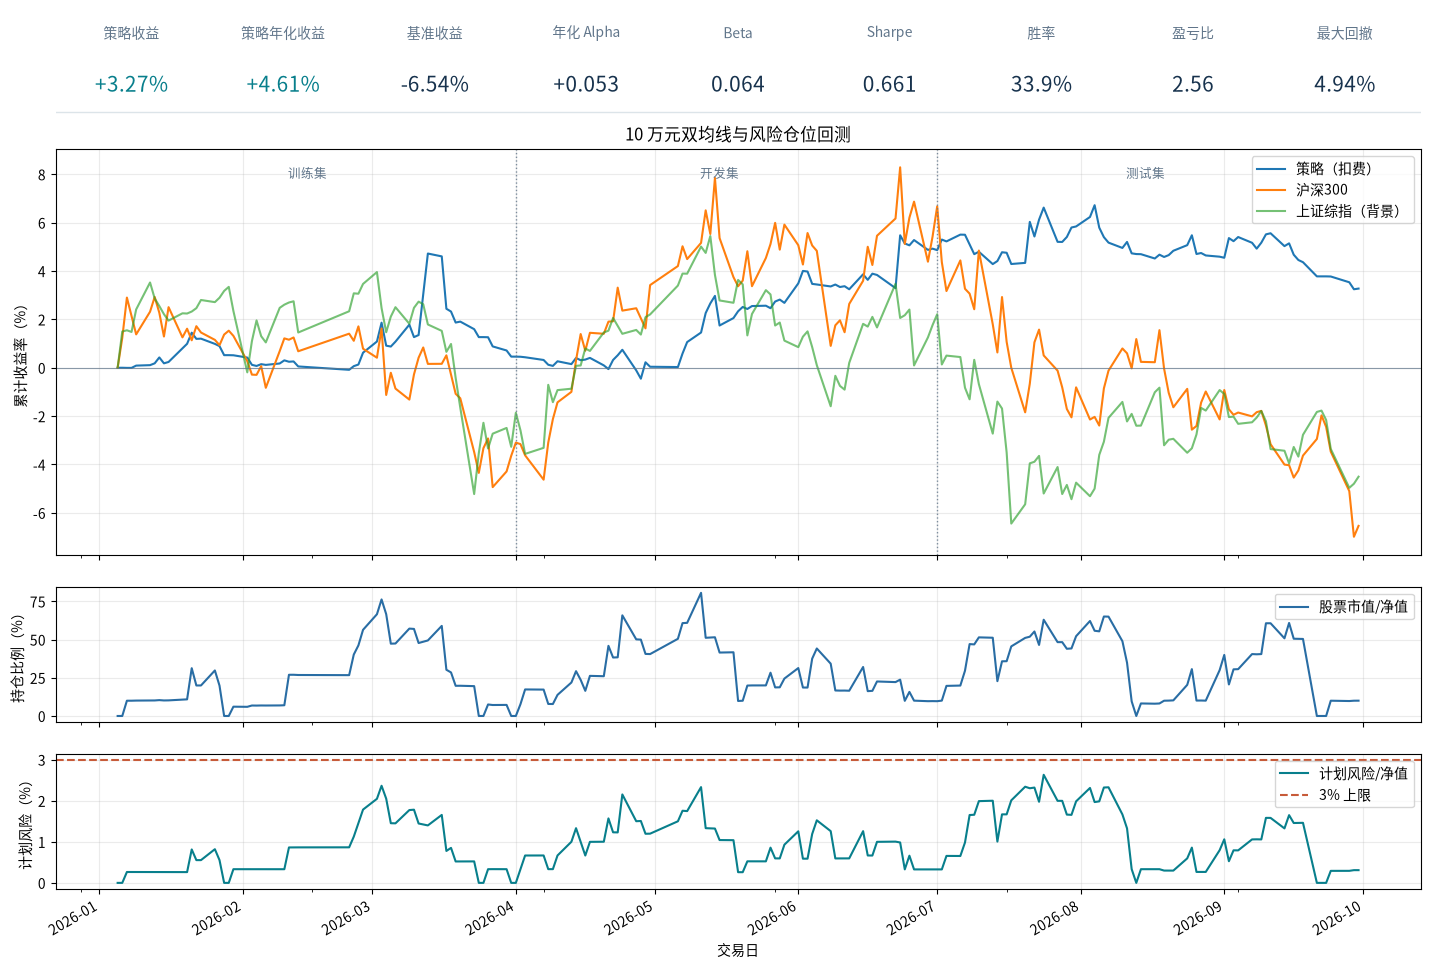

In [10]:
shanghai = shanghai_raw.copy()
shanghai['date'] = pd.to_datetime(shanghai['date'])
shanghai['close'] = pd.to_numeric(shanghai['close'])
shanghai = shanghai.set_index('date')['close'].reindex(nav.index)
shanghai = shanghai / shanghai.iloc[0]

# 指标和曲线放在同一张图里，便于截图时连同统计口径一起阅读。
metric_cards = [
    ('策略收益', f"{m['总收益率']:+.2%}"),
    ('策略年化收益', f"{m['复合年化收益率']:+.2%}"),
    ('基准收益', f"{m['基准总收益率']:+.2%}"),
    ('年化 Alpha', f"{m['Alpha（日回归截距×252）']:+.3f}"),
    ('Beta', f"{m['Beta']:.3f}"),
    ('Sharpe', f"{m['夏普比率']:.3f}"),
    ('胜率', f"{trade_stats['胜率']:.1%}" if np.isfinite(trade_stats['胜率']) else '—'),
    ('盈亏比', f"{trade_stats['盈亏比']:.2f}" if np.isfinite(trade_stats['盈亏比']) else '—'),
    ('最大回撤', f"{abs(m['最大回撤']):.2%}"),
]
fig = plt.figure(figsize=(15, 10), facecolor='white')
grid = fig.add_gridspec(4, 1, height_ratios=[0.8, 3, 1, 1], hspace=0.16)
summary_ax = fig.add_subplot(grid[0])
curve_ax = fig.add_subplot(grid[1])
exposure_ax = fig.add_subplot(grid[2], sharex=curve_ax)
risk_ax = fig.add_subplot(grid[3], sharex=curve_ax)
summary_ax.set_axis_off()
for j, (label, value) in enumerate(metric_cards):
    x = (j + 0.5) / len(metric_cards)
    summary_ax.text(x, .78, label, transform=summary_ax.transAxes,
                    ha='center', va='center', color='#60758a', fontsize=10)
    color = '#087f8c' if label in ('策略收益', '策略年化收益') and value.startswith('+') else '#17324d'
    summary_ax.text(x, .31, value, transform=summary_ax.transAxes,
                    ha='center', va='center', color=color, fontsize=15, fontweight='bold')
summary_ax.plot([0, 1], [.05, .05], transform=summary_ax.transAxes,
                color='#dce4e9', linewidth=1)
((nav[['nav', 'benchmark_nav']] - 1) * 100).rename(columns={
    'nav': '策略（扣费）', 'benchmark_nav': '沪深300'}).plot(ax=curve_ax)
((shanghai - 1) * 100).plot(ax=curve_ax, label='上证综指（背景）', alpha=.65)
curve_ax.axhline(0, color='#60758a', linewidth=.8, alpha=.7)
curve_ax.set(ylabel='累计收益率（%）', title='10 万元双均线与风险仓位回测')
curve_ax.grid(alpha=.25)
# 三段只有评价日期不同；竖线帮助读者看到严格的时间边界。
for boundary in (DEV_START, TEST_START):
    curve_ax.axvline(pd.Timestamp(boundary), color='#60758a',
                     linestyle=':', linewidth=1, alpha=.8)
for mid, label in [('2026-02-15', '训练集'),
                   ('2026-05-15', '开发集'),
                   ('2026-08-15', '测试集')]:
    curve_ax.text(pd.Timestamp(mid), .94, label,
                  transform=curve_ax.get_xaxis_transform(),
                  ha='center', va='center', color='#60758a', fontsize=9)
curve_ax.legend()
(nav.exposure * 100).plot(ax=exposure_ax, color='#296da4', label='股票市值/净值')
exposure_ax.set(ylabel='持仓比例（%）')
exposure_ax.grid(alpha=.25); exposure_ax.legend()
(nav.planned_risk_pct * 100).plot(ax=risk_ax, color='#087f8c', label='计划风险/净值')
risk_ax.axhline(TOTAL_RISK * 100, color='#c75b39', linestyle='--', label=f'{TOTAL_RISK:.0%} 上限')
risk_ax.set(ylabel='计划风险（%）', xlabel='交易日')
risk_ax.grid(alpha=.25)
risk_ax.legend()
plt.setp(curve_ax.get_xticklabels(), visible=False)
plt.setp(exposure_ax.get_xticklabels(), visible=False)
fig.subplots_adjust(left=.07, right=.98, top=.96, bottom=.08)
plt.show()


## 模块 8｜可选：每阶段交易 GIF

每帧对应一个 5 交易日调池阶段，列出买卖股票名称、方向、**复权单位**与**模拟金额**。加仓会在买入侧累计，触发原因见 `trades.reason`，首次与最近一次买价可查 `holdings`。这只是账本可视化，不是实盘订单。

36 个阶段，136 条阶段交易汇总


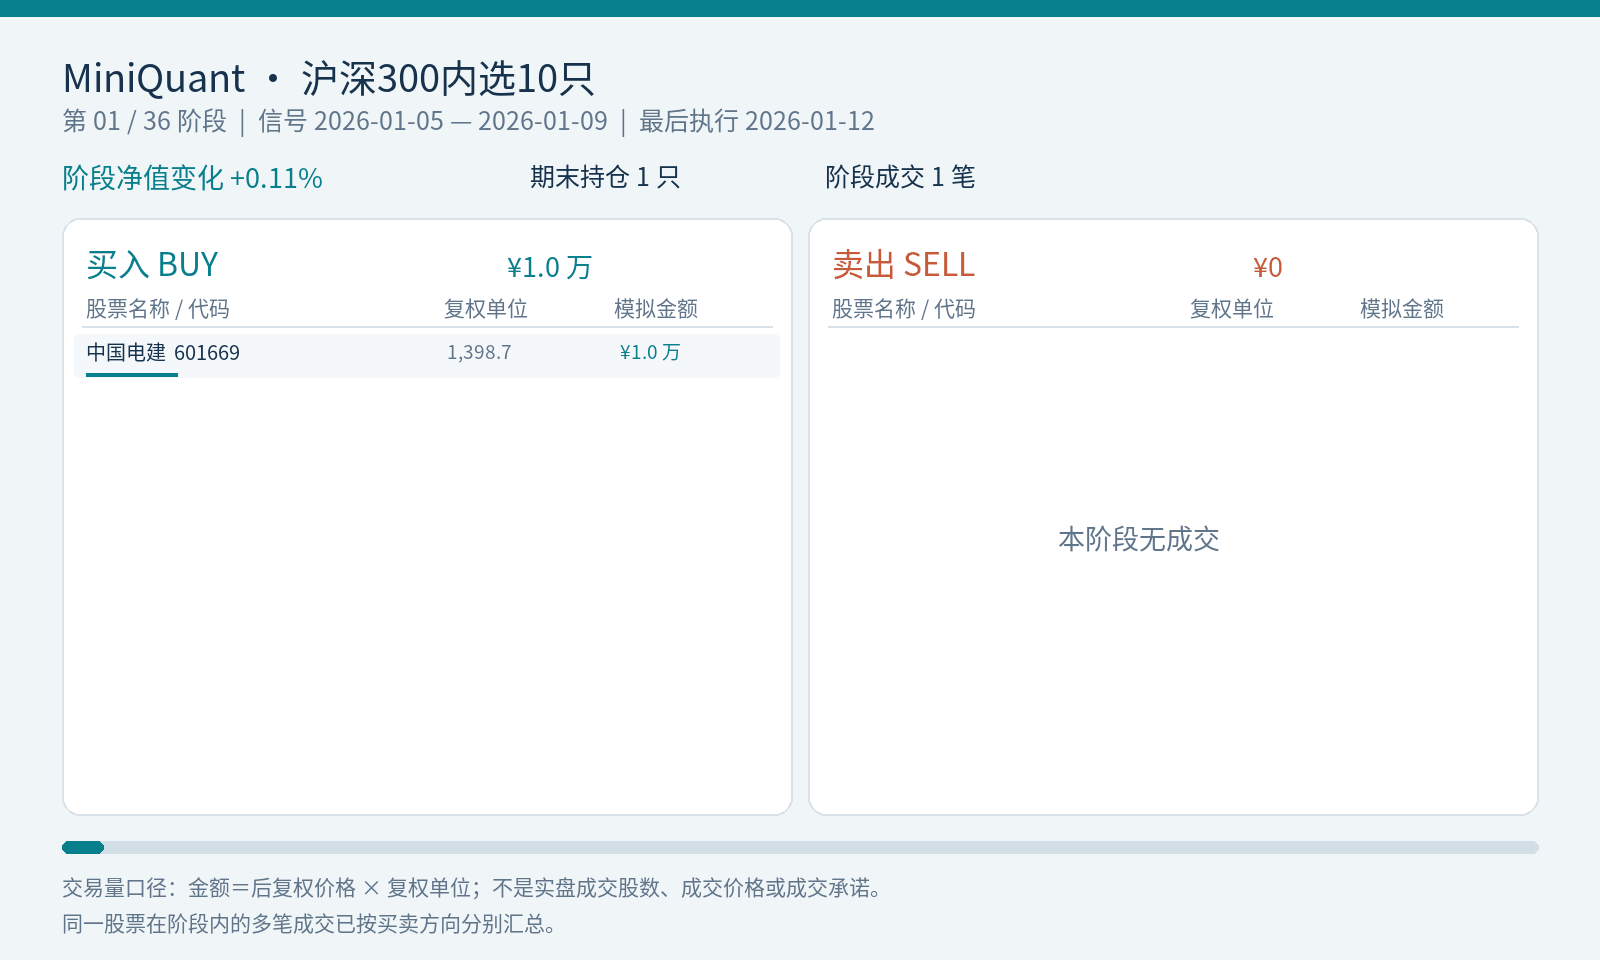

In [11]:
from PIL import Image, ImageDraw, ImageFont

FONT = Path('video/assets/NotoSansCJKsc-Regular.otf')
SIZE = (1600, 960)
INK, MUTED, BUY, SELL = '#17324d', '#60758a', '#087f8c', '#c75b39'

def phase_trade_table(trades: pd.DataFrame, decisions: pd.DataFrame,
                      members: pd.DataFrame) -> pd.DataFrame:
    """Aggregate every executed order by seven-day phase, side and stock."""
    starts = pd.to_datetime(decisions.loc[decisions["rebalance"], "signal_date"])
    if starts.empty or not starts.is_monotonic_increasing:
        raise ValueError("Missing or unordered phase boundaries")
    frame = trades.copy()
    frame["phase"] = np.searchsorted(starts.to_numpy(), frame["signal_date"].to_numpy(), side="right") - 1
    if (frame["phase"] < 0).any() or (frame["phase"] >= len(starts)).any():
        raise ValueError("A trade has no matching phase")
    if not (frame["date"] > frame["signal_date"]).all():
        raise ValueError("Trade preceded its signal")
    frame["notional"] = frame["units"] * frame["adjusted_price"]
    names = members.drop_duplicates("code").set_index("code")["code_name"]
    frame["name"] = frame["code"].map(names)
    if frame["name"].isna().any() or not frame["notional"].gt(0).all():
        raise ValueError("Missing stock name or nonpositive simulated trade amount")
    result = frame.groupby(["phase", "side", "code", "name"], as_index=False).agg(
        adjusted_units=("units", "sum"),
        simulated_notional=("notional", "sum"),
        executions=("code", "size"),
    )
    if not np.isclose(result["simulated_notional"].sum(), frame["notional"].sum()):
        raise ValueError("Animated trade amounts do not reconcile to the ledger")
    return result.sort_values(["phase", "side", "simulated_notional"],
                              ascending=[True, True, False]).reset_index(drop=True)


def _font(size: int) -> ImageFont.FreeTypeFont:
    if not FONT.exists():
        raise FileNotFoundError(f"Bundled Chinese font missing: {FONT.name}")
    return ImageFont.truetype(str(FONT), size)


def _money(amount: float) -> str:
    if amount >= 10_000:
        return f"¥{amount / 10_000:,.1f} 万"
    return f"¥{amount:,.0f}"


def _side(draw: ImageDraw.ImageDraw, rows: pd.DataFrame, *, left: int,
          title: str, color: str, max_rows: int, max_notional: float) -> None:
    draw.rounded_rectangle((left, 218, left + 730, 815), radius=18,
                           fill="#ffffff", outline="#d9e2e9", width=2)
    draw.text((left + 24, 238), title, font=_font(32), fill=color)
    amount = rows["simulated_notional"].sum()
    draw.text((left + 445, 245), _money(amount), font=_font(27), fill=color)
    draw.text((left + 24, 291), "股票名称 / 代码", font=_font(21), fill=MUTED)
    draw.text((left + 382, 291), "复权单位", font=_font(21), fill=MUTED)
    draw.text((left + 552, 291), "模拟金额", font=_font(21), fill=MUTED)
    draw.line((left + 20, 326, left + 710, 326), fill="#d9e2e9", width=2)
    if rows.empty:
        draw.text((left + 250, 517), "本阶段无成交", font=_font(27), fill=MUTED)
        return
    row_height = min(43, 474 // max_rows)
    for i, row in enumerate(rows.itertuples(index=False)):
        y = 336 + i * row_height
        if i % 2 == 0:
            draw.rounded_rectangle((left + 12, y - 2, left + 717, y + row_height - 2),
                                   radius=5, fill="#f5f8fa")
        code = row.code.split(".")[-1]
        draw.text((left + 24, y), f"{row.name}  {code}", font=_font(20), fill=INK)
        draw.text((left + 385, y), f"{row.adjusted_units:,.1f}", font=_font(19), fill=MUTED)
        draw.text((left + 558, y), _money(row.simulated_notional), font=_font(19), fill=color)
        bar_width = int(300 * row.simulated_notional / max_notional)
        draw.rectangle((left + 24, y + row_height - 6,
                        left + 24 + bar_width, y + row_height - 3), fill=color)


def make_trade_animation(trades: pd.DataFrame, decisions: pd.DataFrame,
                         members: pd.DataFrame, nav: pd.DataFrame,
                         out_path: str | Path, duration_ms: int = 2500) -> pd.DataFrame:
    """Save a GIF with one frame per rebalance phase and return its audit table."""
    if duration_ms < 200:
        raise ValueError("Animation duration must allow the table to be read")
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    table = phase_trade_table(trades, decisions, members)
    reset = decisions.reset_index(drop=True)
    boundaries = list(reset.index[reset["rebalance"]]) + [len(reset)]
    max_rows = max(1, int(table.groupby(["phase", "side"]).size().max()))
    if max_rows > 12:
        raise ValueError(f"More than 12 distinct names in a phase side: {max_rows}")
    max_notional = max(float(table["simulated_notional"].max()), 1.0)
    frames = []
    for phase, (begin, stop) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        block = reset.iloc[begin:stop]
        signal_start = block["signal_date"].iloc[0]
        signal_end = block["signal_date"].iloc[-1]
        executed_end = block["execution_date"].iloc[-1]
        phase_nav = nav.loc[executed_end, "nav"] / nav.loc[signal_start, "nav"] - 1
        holdings = int(nav.loc[executed_end, "holdings"])
        selected = table.loc[table["phase"] == phase]
        buys = selected.loc[selected["side"] == "BUY"]
        sells = selected.loc[selected["side"] == "SELL"]

        image = Image.new("RGB", SIZE, "#f0f5f8")
        draw = ImageDraw.Draw(image)
        draw.rectangle((0, 0, SIZE[0], 16), fill=BUY)
        draw.text((62, 47), "MiniQuant · 沪深300内选10只", font=_font(38), fill=INK)
        draw.text((62, 101),
                  f"第 {phase + 1:02d} / {len(boundaries)-1:02d} 阶段  |  信号 {signal_start.date()} — {signal_end.date()}"
                  f"  |  最后执行 {executed_end.date()}", font=_font(25), fill=MUTED)
        gain_color = BUY if phase_nav >= 0 else SELL
        draw.text((62, 156), f"阶段净值变化 {phase_nav:+.2%}", font=_font(27), fill=gain_color)
        draw.text((530, 157), f"期末持仓 {holdings} 只", font=_font(25), fill=INK)
        draw.text((825, 157), f"阶段成交 {int(selected['executions'].sum())} 笔", font=_font(25), fill=INK)
        _side(draw, buys, left=62, title="买入 BUY", color=BUY,
              max_rows=max_rows, max_notional=max_notional)
        _side(draw, sells, left=808, title="卖出 SELL", color=SELL,
              max_rows=max_rows, max_notional=max_notional)
        progress = (phase + 1) / (len(boundaries) - 1)
        draw.rounded_rectangle((62, 841, 1538, 853), radius=6, fill="#d2dfe7")
        draw.rounded_rectangle((62, 841, 62 + int(1476 * progress), 853),
                               radius=6, fill=BUY)
        draw.text((62, 870),
                  "交易量口径：金额＝后复权价格 × 复权单位；不是实盘成交股数、成交价格或成交承诺。",
                  font=_font(21), fill=MUTED)
        draw.text((62, 906), "同一股票在阶段内的多笔成交已按买卖方向分别汇总。",
                  font=_font(21), fill=MUTED)
        frames.append(image.convert("P", palette=Image.Palette.ADAPTIVE, colors=128))
    temp = out_path.with_name(out_path.stem + ".part.gif")
    frames[0].save(temp, save_all=True, append_images=frames[1:],
                   duration=duration_ms, loop=0, optimize=True, disposal=2)
    temp.replace(out_path)
    return table


gif_path = Path('figs/simple_framework_trades.gif')
phase_trades = make_trade_animation(trades, decisions, members, nav, gif_path)
print(f'{int(decisions.rebalance.sum())} 个阶段，{len(phase_trades)} 条阶段交易汇总')
display(NotebookImage(filename=str(gif_path), embed=True))

## 参数实验｜训练集确认逻辑，开发集选参，测试集只验一次

三个评价集严格互斥：**训练集 2026-01-05—03-31** 用来检查信号、费用、时序和风险仓位是否按设计工作；**开发集 04-01—06-30** 只用来筛选候选参数；**测试集 07-01—09-30** 在参数冻结后才输出一次，不参与排序。下面的可选代码默认关闭，打开 `RUN_PARAMETER_LAB` 后依次粗筛选股与均线、细调风控、再研究仓位。过拟合仍可能发生：开发集只有约三个月，搜索近百组参数，很容易选中偶然的赢家。

“不重叠”指三个区间的**每日收益标签**只归属一个区间；跨边界计算 MA 可以使用边界前已经发生的日线，持仓状态也可以连续传递，不能使用边界后的价格生成边界前的决策。更严格的独立测试需要**尚未观察过的未来数据**。我们此前已经多次查看过 2026 年 7—9 月结果，本页的“测试集”只是正确切分方法的演示，不能重新宣称为盲测。把回测搬上实盘前，还需用新月份、滚动窗口以及可成交价格、整手和限价约束继续验证。


In [12]:
RUN_PARAMETER_LAB = False  # 设为 True 才搜索；默认只阅读已执行的回测

def development_score(candidate_nav):
    """Only the development dates score parameters; never read test P&L here."""
    dev = period_metrics(candidate_nav, DEV_START, DEV_END)
    return {'开发收益': dev['策略收益'], '开发超额': dev['简单超额'],
            '开发最大回撤': dev['策略最大回撤'], '开发费用/本金': dev['费用/本金']}


if RUN_PARAMETER_LAB:
    from itertools import product

    knobs = ['MA_FAST', 'MA_SLOW', 'PE_UPPER', 'REBALANCE_EVERY',
             'INITIAL_STOP', 'ARM_GAIN', 'TRAIL_BACK', 'ADD_PROFIT_STEP', 'ATR_MULT',
             'TOTAL_RISK', 'NAME_RISK', 'MAX_NAME_WEIGHT']
    saved = {key: globals()[key] for key in knobs}
    try:
        # 训练集只验逻辑：这里保留朴素仓位，检查收益日数和信号时序。
        TOTAL_RISK, NAME_RISK, MAX_NAME_WEIGHT = 0.01, 0.002, 0.10
        train_bars = bars.loc[bars.date <= pd.Timestamp(TRAIN_END)]
        train_benchmark = benchmark.loc[benchmark.date <= pd.Timestamp(TRAIN_END)]
        train_decisions = build_decisions(train_bars, reports, train_benchmark,
                                          every=REBALANCE_EVERY)
        train_nav, train_trades, _ = run_risk_backtest(
            train_bars, train_benchmark, train_decisions)
        train_check = period_metrics(train_nav, TRAIN_START, TRAIN_END)
        assert train_check['收益日数'] > 20
        assert train_trades.empty or (train_trades.date > train_trades.signal_date).all()
        assert train_nav.planned_risk_pct.max() <= TOTAL_RISK + 1e-9
        print('训练集：先检查时序、风险预算和基础信号；不据此选最优参数')
        display(pd.DataFrame([train_check]))

        # 搜索期间物理上不提供测试期行情，避免候选回测偷偷计算测试收益。
        research_bars_raw = bars_raw.loc[
            pd.to_datetime(bars_raw.date) <= pd.Timestamp(DEV_END)]
        research_benchmark_raw = benchmark_raw.loc[
            pd.to_datetime(benchmark_raw.date) <= pd.Timestamp(DEV_END)]
        assert pd.to_datetime(research_bars_raw.date).max() <= pd.Timestamp(DEV_END)
        assert pd.to_datetime(research_benchmark_raw.date).max() <= pd.Timestamp(DEV_END)
        coarse = []
        for fast, slow, upper, every in product((3, 5, 8), (10, 15, 20),
                                                 (30., 25.), (5, 7)):
            if fast >= slow:
                continue
            MA_FAST, MA_SLOW, PE_UPPER, REBALANCE_EVERY = fast, slow, upper, every
            test_bars, test_reports, _, test_benchmark, _ = clean_inputs(
                research_bars_raw, reports_raw, members_raw, research_benchmark_raw, slow)
            test_decisions = build_decisions(test_bars, test_reports, test_benchmark,
                                             every=every)
            candidate_nav, _, _ = run_risk_backtest(test_bars, test_benchmark,
                                                     test_decisions)
            coarse.append({'快线': fast, '慢线': slow, 'PE上限': upper, '调池天数': every,
                           **development_score(candidate_nav)})
        coarse = pd.DataFrame(coarse).sort_values('开发收益', ascending=False, kind='stable')
        print('开发集第一步：筛选股池与双均线')
        display(coarse.head(8).reset_index(drop=True))
        winner = coarse.iloc[0]
        MA_FAST, MA_SLOW, PE_UPPER, REBALANCE_EVERY = (
            int(winner['快线']), int(winner['慢线']), float(winner['PE上限']),
            int(winner['调池天数']))
        tuned_bars, tuned_reports, _, tuned_benchmark, _ = clean_inputs(
            research_bars_raw, reports_raw, members_raw, research_benchmark_raw, MA_SLOW)
        tuned_decisions = build_decisions(tuned_bars, tuned_reports, tuned_benchmark,
                                          every=REBALANCE_EVERY)

        fine = []
        for stop, arm, trail, step, atr in product(
                (.025, .03), (.06, .08), (.025, .03), (.02, .03), (1.5, 2.0)):
            INITIAL_STOP, ARM_GAIN, TRAIL_BACK = stop, arm, trail
            ADD_PROFIT_STEP, ATR_MULT = step, atr
            candidate_nav, _, _ = run_risk_backtest(tuned_bars, tuned_benchmark,
                                                     tuned_decisions)
            fine.append({'止损': stop, '启动止盈': arm, '峰值回撤': trail,
                         '加仓步长': step, 'ATR倍数': atr,
                         **development_score(candidate_nav)})
        fine = pd.DataFrame(fine).sort_values('开发收益', ascending=False, kind='stable')
        print('开发集第二步：细调退出与加仓')
        display(fine.head(8).reset_index(drop=True))
        best = fine.iloc[0]
        INITIAL_STOP, ARM_GAIN, TRAIL_BACK = (
            float(best['止损']), float(best['启动止盈']), float(best['峰值回撤']))
        ADD_PROFIT_STEP, ATR_MULT = float(best['加仓步长']), float(best['ATR倍数'])

        exposure_tests = []
        for total, name, weight in product((.01, .02, .03, .05),
                                            (.002, .004, .006, .008, .01),
                                            (.10, .20, .30)):
            if name > total:
                continue
            TOTAL_RISK, NAME_RISK, MAX_NAME_WEIGHT = total, name, weight
            candidate_nav, _, _ = run_risk_backtest(tuned_bars, tuned_benchmark,
                                                     tuned_decisions)
            exposure_tests.append({'总风险': total, '单股风险': name, '单股市值': weight,
                                   '平均持仓比例': candidate_nav.exposure.mean(),
                                   **development_score(candidate_nav)})
        exposure_tests = pd.DataFrame(exposure_tests).sort_values(
            '开发收益', ascending=False, kind='stable')
        print('开发集第三步：调仓位，观察收益与回撤')
        display(exposure_tests.head(10).reset_index(drop=True))
        near_best = exposure_tests.loc[
            exposure_tests['开发收益'] >= exposure_tests['开发收益'].max() - .001]
        chosen = near_best.sort_values(['总风险', '单股风险', '单股市值']).iloc[0]
        TOTAL_RISK, NAME_RISK, MAX_NAME_WEIGHT = (
            float(chosen['总风险']), float(chosen['单股风险']), float(chosen['单股市值']))

        # 参数至此冻结；现在才读取完整行情，测试期没有进入任何候选搜索。
        full_bars, full_reports, _, full_benchmark, _ = clean_inputs(
            bars_raw, reports_raw, members_raw, benchmark_raw, MA_SLOW)
        full_decisions = build_decisions(full_bars, full_reports, full_benchmark,
                                         every=REBALANCE_EVERY)
        chosen_nav, _, _ = run_risk_backtest(full_bars, full_benchmark,
                                             full_decisions)
        print('参数已冻结；测试集只验证一次（本历史时段此前已被看过）')
        display(pd.DataFrame([period_metrics(chosen_nav, TEST_START, TEST_END)]))
        print('完整区间仅作描述，不能回头据此更改参数')
        display(pd.DataFrame([performance_metrics(chosen_nav)]))
    finally:
        globals().update(saved)
else:
    print('参数实验默认关闭；设 RUN_PARAMETER_LAB=True 可按训练→开发→测试顺序练习。')


参数实验默认关闭；设 RUN_PARAMETER_LAB=True 可按训练→开发→测试顺序练习。


## 如何理解这次结果：回测好不等于能上实盘

默认图表展示的是**开发集选参方案**：MA5/MA15、每 5 日调池、初始止损 2.5%、涨幅达到 8% 后峰值回撤 2.5%、+2%/+4% 等额加仓、风险距离 `max(2.5%, 1.5×ATR14/收盘价)`，组合/个股计划风险预算分别为 **3%/1%**，单股市值上限 **30%**。选参时只用 4—6 月开发集收益排序；1—3 月训练集负责确认程序逻辑，7—9 月测试集不参与参数搜索。三个区间的每日收益日期不重叠。

这组参数在完整 1—9 月约有 **+3.27%** 收益、复合年化换算 **+4.61%**、最大回撤 **4.94%**；沪深 300 价格指数分别约为 **−6.54%**、**−9.03%** 和 **14.11%**。但按开发集挑出参数后，测试集策略收益是 **−1.57%**：相对大盘虽有超额，绝对收益却为负，不能据此投入实盘。此前查看完整走势后得到的探索性配置显示约 **+5.01%**、年化换算 **+7.09%**；那是历史信息参与选择后的结果，不能拿来充当测试验证。现在即使按三段重新切分，我们也已看过 7—9 月历史，所以它仍只是教学上的**模拟测试**。真正的盲测必须等待未见过的新月份数据，并事先锁定代码、参数和费用口径。

这段样本旧风险预算 1%/0.2%、单股市值上限 10% 时，平均仅约 5.9% 的资金投在股票里，曲线显得平；提高预算会同时放大盈亏与集中度。**计划风险不保证最大亏损**，跳空、停牌、涨跌停和真实佣金均可能使结果更差。固定初始成分股、历史财报修订、后复权价和分数复权单位也与真实下单存在差距。年化值是短样本外推，并非实际持有一年的收益。

**来源**：[BaoStock 官网/API](https://www.baostock.com/) · [BaoStock 复权说明](https://www.baostock.com/helpdocs/pdf/BaoStock%E5%A4%8D%E6%9D%83%E5%9B%A0%E5%AD%90%E7%AE%80%E4%BB%8B.pdf) · [东方财富财报数据中心](https://data.eastmoney.com/bbsj/)。公开仓库不打包原始网页数据，首次运行会缓存到 `data/private/`。

费率来源：[上交所股票交易费用说明](https://one.sse.com.cn/onething/gptz/)列出卖出印花税 0.5‰、过户费 0.01‰ 和佣金最低 5 元；[财政部与税务总局 2023 年公告](https://szs.mof.gov.cn/zhengcefabu/202308/t20230827_3904226.htm)规定证券交易印花税减半。佣金万三只是本例假设，请按自己的券商账户修改。
